# 🛣️ Streetlight Fault Detection System

> **Dual-output model**: Bounding boxes with Light Status (`Light_On` / `Light_Off`) + Scene Condition (`Daylight` / `Twilight` / `Night`)

---

| Component | Model | Output |
|-----------|-------|--------|
| Detection | YOLOv8 | Bounding box + Light status |
| Classification | MobileNetV2 | Scene condition (Daylight / Twilight / Night) |

**Dataset**: Roboflow — `aymans-workplace/street-light-2 v2`  
**Formats**: COCO JSON (classification) + YOLOv8 (detection)

---

## 1. 📦 Install Dependencies

In [1]:
!pip install -q pandas tensorflow opencv-python matplotlib scikit-learn roboflow
!pip install -q torch torchvision ultralytics
!pip install -q Pillow tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 67.7 MB/s eta 0:00:00


## 2. 📚 Import Libraries

In [2]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from collections import Counter

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# YOLO
from ultralytics import YOLO

print(f"TensorFlow  : {tf.__version__}")
print(f"OpenCV      : {cv2.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
TensorFlow  : 2.19.0
OpenCV      : 4.10.0
GPU available: True


## 3. 📥 Load Dataset from Roboflow

Downloads **two formats** from the same project version:
- `coco` → used to extract image-level tags (scene condition) for the classifier
- `yolov8` → used to train the detection model

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="MYAPI")  # ← Replace with valid API key
project = rf.workspace("aymans-workplace").project("street-light-2")
version  = project.version(2)

coco_dataset = version.download("coco",    location="/content/coco_dataset")
yolo_dataset = version.download("yolov8", location="/content/yolo_dataset")

print("COCO root :", coco_dataset.location)
print("YOLO root :", yolo_dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/coco_dataset in coco:: 100%|██████████| 2200/2200 [00:00<00:00, 5439.36it/s]


Extracting Dataset Version Zip to /content/yolo_dataset in yolov8:: 100%|██████████| 4395/4395 [00:00<00:00, 6320.11it/s]

COCO root : /content/coco_dataset
YOLO root : /content/yolo_dataset


### 3.1 Inspect COCO Annotation Structure

In [4]:
coco_root = coco_dataset.location

with open(f"{coco_root}/train/_annotations.coco.json") as f:
    coco_train = json.load(f)
with open(f"{coco_root}/test/_annotations.coco.json") as f:
    coco_test  = json.load(f)
with open(f"{coco_root}/valid/_annotations.coco.json") as f:
    coco_valid = json.load(f)

print("Top-level keys :", list(coco_train.keys()))
print(f"Train images   : {len(coco_train['images'])}")
print(f"Train annots   : {len(coco_train['annotations'])}")
print("Categories     :", coco_train["categories"])

Top-level keys : ['info', 'licenses', 'categories', 'images', 'annotations']
Train images   : 1977
Train annots   : 3072
Categories     : [{'id': 0, 'name': 'objects-tc2Q', 'supercategory': 'none'}, {'id': 1, 'name': 'Light_Off', 'supercategory': 'objects-tc2Q'}, {'id': 2, 'name': 'Light_On', 'supercategory': 'objects-tc2Q'}]


### 3.2 Extract Image-Level Tags (Scene Condition)

In [5]:
print("Sample image metadata with tags:\n")
for img in coco_train["images"][:5]:
    tags = img.get("extra", {}).get("user_tags", [])
    print(f"  {img['file_name']:50s}  tags → {tags}")

# Aggregate tag distribution across training set
all_tags = []
for img in coco_train["images"]:
    tags = img.get("extra", {}).get("user_tags", [])
    all_tags.extend(tags)

tag_counts = Counter(all_tags)
print("\nTag distribution (train):", dict(tag_counts))

Sample image metadata with tags:

  IMG-20240309-WA0020_jpg.rf.1c675b50725663c2bbbf4b4217c84744.jpg  tags → ['Night']
  20240309_191648_jpg.rf.9f0e9c40d9ca4e9f09956aee99eefecf.jpg  tags → ['Night']
  20240305_190518_jpg.rf.b2c13bd51d45361d9f6f60e5b082856e.jpg  tags → ['Night']
  1710175824152_jpg.rf.efdb56e9039893ab5e9e74d045f3958c.jpg  tags → ['Night']
  IMG_20240229_182617_jpg.rf.c3afbd242360dcb565f6e10414d852f2.jpg  tags → ['Twilight']

Tag distribution (train): {'Night': 1587, 'Twilight': 270, 'Daylight': 120}


### 3.3 Visualise Sample Annotated Images

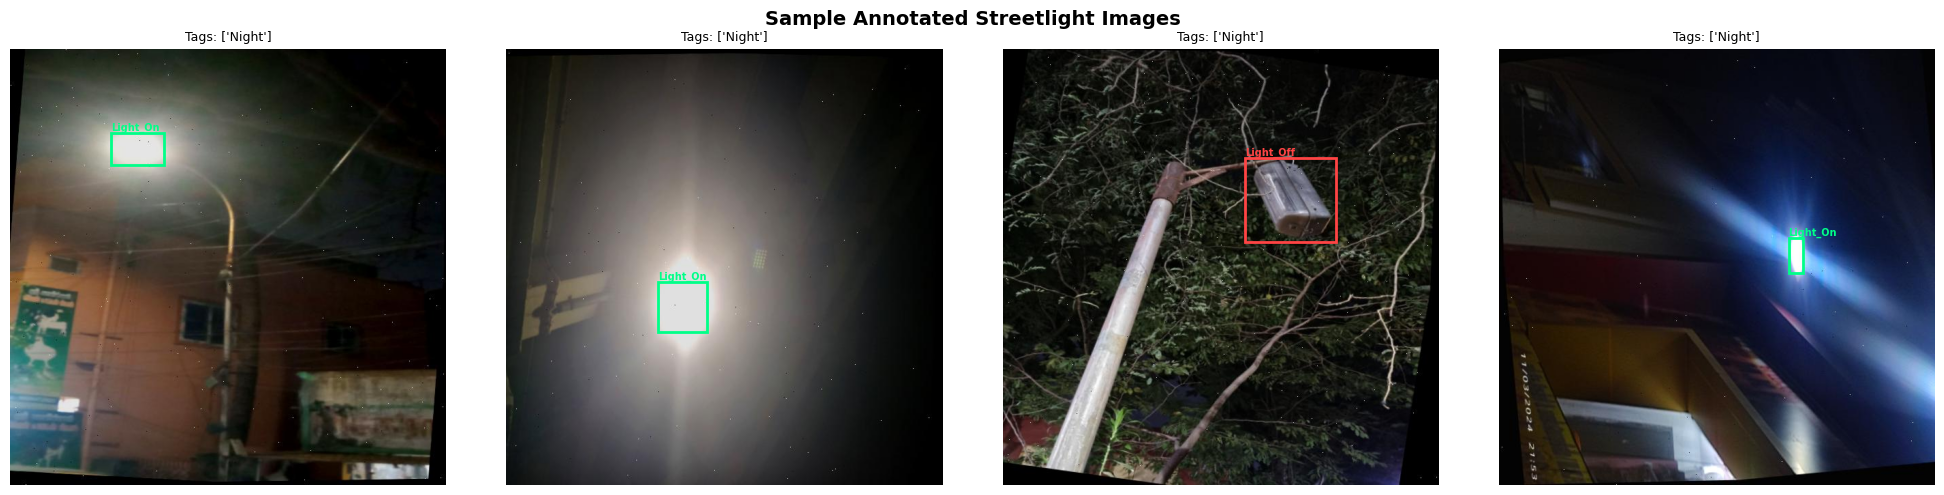

In [6]:
# Build helper look-ups
id2cat   = {c["id"]: c["name"] for c in coco_train["categories"]}
id2img   = {img["id"]: img    for img in coco_train["images"]}
img2anns = {}
for ann in coco_train["annotations"]:
    img2anns.setdefault(ann["image_id"], []).append(ann)

COLOUR = {"Light_On": "#00FF88", "Light_Off": "#FF4444"}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Sample Annotated Streetlight Images", fontsize=14, fontweight="bold")

sample_ids = list(id2img.keys())[:4]
for ax, img_id in zip(axes, sample_ids):
    meta      = id2img[img_id]
    img_path  = os.path.join(coco_root, "train", meta["file_name"])
    image     = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB) if os.path.exists(img_path) else np.zeros((416,416,3), dtype=np.uint8)
    tags      = meta.get("extra", {}).get("user_tags", ["Unknown"])

    ax.imshow(image)
    for ann in img2anns.get(img_id, []):
        x, y, w, h = ann["bbox"]
        label      = id2cat[ann["category_id"]]
        colour     = COLOUR.get(label, "yellow")
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=colour, facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y - 4, label, color=colour, fontsize=7, fontweight="bold")

    ax.set_title(f"Tags: {tags}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. 🏷️ Label Engineering

Map raw annotations into two clean numeric targets:

| Raw source | Target | Mapping |
|------------|--------|---------|
| COCO `category` | `light_status` | `Light_Off` → 0, `Light_On` → 1 |
| COCO `user_tags` | `condition` | `Night` → 0, `Twilight` → 1, `Daylight` → 2 |

In [7]:
LIGHT_MAP     = {"Light_Off": 0, "Light_On": 1}
CONDITION_MAP = {"Night": 0, "Twilight": 1, "Daylight": 2}
CONDITION_INV = {v: k for k, v in CONDITION_MAP.items()}
LIGHT_INV     = {v: k for k, v in LIGHT_MAP.items()}

def build_records(coco_data, split_name, img_root):
    """Flatten COCO annotations into a per-annotation DataFrame row."""
    id2cat_local = {c["id"]: c["name"] for c in coco_data["categories"]}
    id2img_local = {img["id"]: img      for img in coco_data["images"]}
    records      = []

    for ann in coco_data["annotations"]:
        img_meta  = id2img_local[ann["image_id"]]
        tags      = img_meta.get("extra", {}).get("user_tags", [])
        condition = next((CONDITION_MAP[t] for t in tags if t in CONDITION_MAP), -1)
        label     = id2cat_local[ann["category_id"]]

        records.append({
            "split"        : split_name,
            "image_id"     : ann["image_id"],
            "file_name"    : img_meta["file_name"],
            "img_path"     : os.path.join(img_root, img_meta["file_name"]),
            "bbox"         : ann["bbox"],          # [x, y, w, h]
            "light_label"  : label,
            "light_status" : LIGHT_MAP.get(label, -1),
            "condition"    : condition,
            "tags"         : tags,
        })
    return records

records = (
    build_records(coco_train, "train", f"{coco_root}/train") +
    build_records(coco_valid, "valid", f"{coco_root}/valid") +
    build_records(coco_test,  "test",  f"{coco_root}/test")
)

df = pd.DataFrame(records)
print(df.shape)
df.head(3)

(3408, 9)


,split,image_id,file_name,img_path,bbox,light_label,light_status,condition,tags
0,train,0,IMG-20240309-WA0020_jpg.rf.1c675b50725663c2bbb...,/content/coco_dataset/train/IMG-20240309-WA002...,"[148, 123, 77.341, 47.141]",Light_On,1,0,[Night]
1,train,1,20240309_191648_jpg.rf.9f0e9c40d9ca4e9f09956ae...,/content/coco_dataset/train/20240309_191648_jp...,"[222, 342, 72.133, 73.556]",Light_On,1,0,[Night]
2,train,2,20240305_190518_jpg.rf.b2c13bd51d45361d9f6f60e...,/content/coco_dataset/train/20240305_190518_jp...,"[355, 160, 134.481, 122.926]",Light_Off,0,0,[Night]


### 4.1 Dataset Statistics

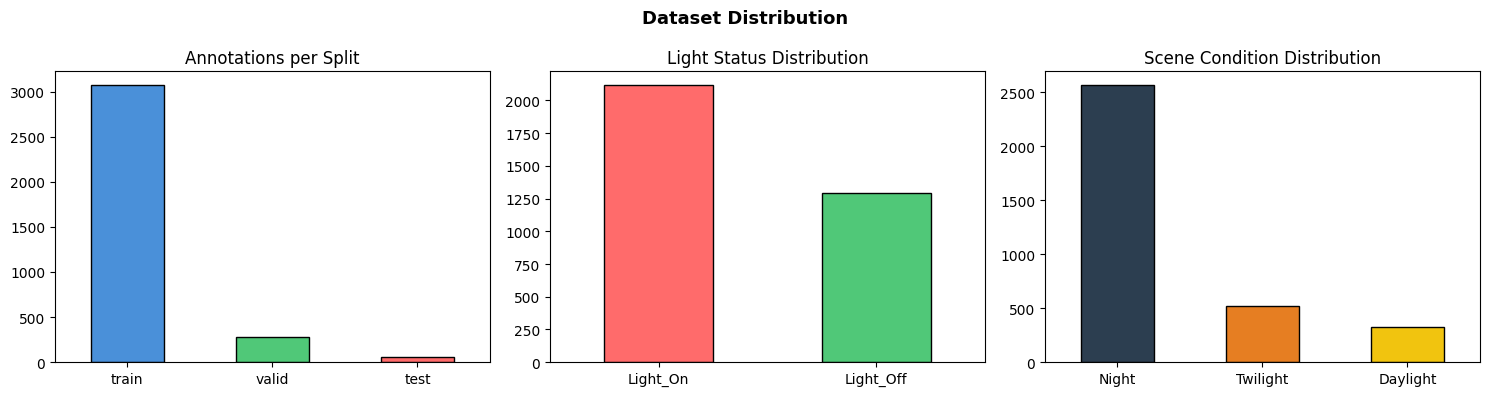

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Dataset Distribution", fontsize=13, fontweight="bold")

# Split
df["split"].value_counts().plot(kind="bar", ax=axes[0], color=["#4A90D9","#50C878","#FF6B6B"], edgecolor="black")
axes[0].set_title("Annotations per Split")
axes[0].set_xlabel("")

# Light status
df["light_label"].value_counts().plot(kind="bar", ax=axes[1], color=["#FF6B6B","#50C878"], edgecolor="black")
axes[1].set_title("Light Status Distribution")
axes[1].set_xlabel("")

# Condition
cond_labels = df["condition"].map(CONDITION_INV).value_counts()
cond_labels.plot(kind="bar", ax=axes[2], color=["#2C3E50","#E67E22","#F1C40F"], edgecolor="black")
axes[2].set_title("Scene Condition Distribution")
axes[2].set_xlabel("")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 5. 🔦 Model 1 — YOLOv8 Detection (Light Status)

Trains a YOLOv8-nano model on the downloaded YOLOv8 dataset.  
**Output**: bounding boxes labeled `Light_On` or `Light_Off`.

In [9]:
# Verify the YOLO data.yaml exists
yolo_root  = yolo_dataset.location
data_yaml  = os.path.join(yolo_root, "data.yaml")

assert os.path.exists(data_yaml), f"data.yaml not found at {data_yaml}"

# Preview yaml
with open(data_yaml) as f:
    print(f.read())

names:
- Light_Off
- Light_On
nc: 2
roboflow:
  license: CC BY 4.0
  project: street-light-2
  url: https://universe.roboflow.com/aymans-workplace/street-light-2/dataset/2
  version: 2
  workspace: aymans-workplace
test: ../test/images
train: ../train/images
val: ../valid/images



In [10]:
# ── Training ──────────────────────────────────────────────────────────────
yolo_model = YOLO("yolov8n.pt")   # nano backbone — swap to yolov8s/m for more accuracy

results = yolo_model.train(
    data    = data_yaml,
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    name    = "streetlight_yolo",
    project = "/content/runs",
    patience= 10,          # early stopping
    verbose = False,
)

print("Best weights saved to:", results.save_dir)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=streetlight_yolo, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

### 5.1 Evaluate YOLOv8 on Validation Set

In [11]:
best_weights = os.path.join(results.save_dir, "weights", "best.pt")
yolo_model   = YOLO(best_weights)

val_metrics = yolo_model.val(data=data_yaml, verbose=False)

print(f"mAP@0.50     : {val_metrics.box.map50:.4f}")
print(f"mAP@0.50:0.95: {val_metrics.box.map:.4f}")
print(f"Precision    : {val_metrics.box.mp:.4f}")
print(f"Recall       : {val_metrics.box.mr:.4f}")

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 889.6±484.9 MB/s, size: 36.9 KB)
val: Scanning /content/yolo_dataset/valid/labels.cache... 175 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 175/175 48.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.9it/s 3.8s
                   all        175        275      0.879      0.659      0.712      0.409
Speed: 4.5ms preprocess, 5.0ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.50     : 0.7123
mAP@0.50:0.95: 0.4092
Precision    : 0.8791
Recall       : 0.6586


### 5.2 Plot YOLOv8 Training Curves

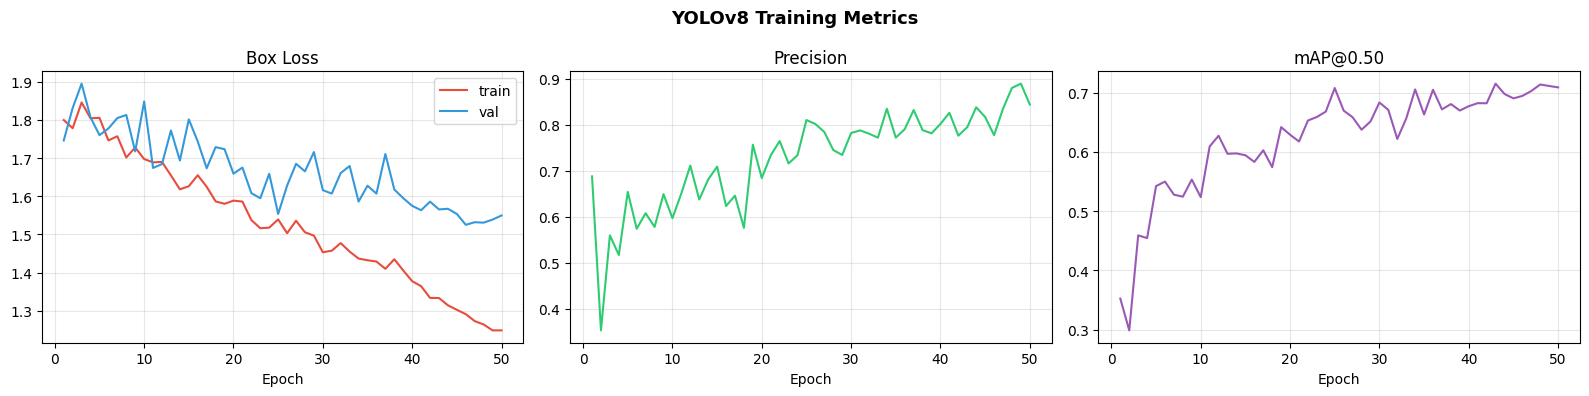

In [12]:
results_csv = os.path.join(results.save_dir, "results.csv")
train_log   = pd.read_csv(results_csv)
train_log.columns = train_log.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("YOLOv8 Training Metrics", fontsize=13, fontweight="bold")

axes[0].plot(train_log["epoch"], train_log["train/box_loss"], label="train", color="#E74C3C")
axes[0].plot(train_log["epoch"], train_log["val/box_loss"],   label="val",   color="#3498DB")
axes[0].set_title("Box Loss"); axes[0].legend()

axes[1].plot(train_log["epoch"], train_log["metrics/precision(B)"], color="#2ECC71")
axes[1].set_title("Precision")

axes[2].plot(train_log["epoch"], train_log["metrics/mAP50(B)"], color="#9B59B6")
axes[2].set_title("mAP@0.50")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 🌅 Model 2 — Scene Condition Classifier (MobileNetV2)

A lightweight MobileNetV2 classifier trained on **full images** (not crops).  
**Output**: one of `Night (0)`, `Twilight (1)`, `Daylight (2)`.

### 6.1 Prepare Classifier Dataset from COCO Tags

In [13]:
# Build per-image (not per-annotation) dataframe with condition labels
def images_with_condition(coco_data, img_root):
    rows = []
    for img in coco_data["images"]:
        tags      = img.get("extra", {}).get("user_tags", [])
        condition = next((CONDITION_MAP[t] for t in tags if t in CONDITION_MAP), None)
        if condition is None:
            continue   # skip images with no recognised condition tag
        rows.append({
            "img_path"  : os.path.join(img_root, img["file_name"]),
            "condition" : condition,
            "label_name": CONDITION_INV[condition],
        })
    return rows

clf_rows = (
    images_with_condition(coco_train, f"{coco_root}/train") +
    images_with_condition(coco_valid, f"{coco_root}/valid") +
    images_with_condition(coco_test,  f"{coco_root}/test")
)

clf_df = pd.DataFrame(clf_rows)
print(clf_df["label_name"].value_counts())
clf_df.head(3)

label_name
Night       1754
Twilight     298
Daylight     143
Name: count, dtype: int64


,img_path,condition,label_name
0,/content/coco_dataset/train/IMG-20240309-WA002...,0,Night
1,/content/coco_dataset/train/20240309_191648_jp...,0,Night
2,/content/coco_dataset/train/20240305_190518_jp...,0,Night


In [14]:
# Organise into folder structure expected by ImageDataGenerator:
#   /content/clf_dataset/train/<label>/img.jpg

import shutil
from sklearn.model_selection import train_test_split

CLF_ROOT = "/content/clf_dataset"

def copy_to_folder(df, split_name):
    for _, row in df.iterrows():
        dst_dir = os.path.join(CLF_ROOT, split_name, row["label_name"])
        os.makedirs(dst_dir, exist_ok=True)
        dst     = os.path.join(dst_dir, os.path.basename(row["img_path"]))
        if os.path.exists(row["img_path"]) and not os.path.exists(dst):
            shutil.copy2(row["img_path"], dst)

train_df, temp_df = train_test_split(clf_df, test_size=0.2, stratify=clf_df["condition"], random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["condition"], random_state=42)

copy_to_folder(train_df, "train")
copy_to_folder(val_df,   "val")
copy_to_folder(test_df,  "test")

print("Classifier dataset ready at", CLF_ROOT)
print(f"  Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

Classifier dataset ready at /content/clf_dataset
  Train: 1756  Val: 219  Test: 220


### 6.2 Build MobileNetV2 Classifier

In [15]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES= 3

train_gen = ImageDataGenerator(
    rescale          = 1./255,
    rotation_range   = 15,
    width_shift_range= 0.1,
    height_shift_range=0.1,
    horizontal_flip  = True,
    brightness_range = [0.7, 1.3],
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    os.path.join(CLF_ROOT, "train"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True
)
val_data = val_gen.flow_from_directory(
    os.path.join(CLF_ROOT, "val"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
test_data = val_gen.flow_from_directory(
    os.path.join(CLF_ROOT, "test"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

CLASS_NAMES = list(train_data.class_indices.keys())
print("Class mapping:", train_data.class_indices)

Found 1756 images belonging to 3 classes.
Found 219 images belonging to 3 classes.
Found 220 images belonging to 3 classes.
Class mapping: {'Daylight': 0, 'Night': 1, 'Twilight': 2}


In [16]:
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False   # freeze backbone initially

clf_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
], name="StreetlightConditionClassifier")

clf_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

clf_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "StreetlightConditionClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,811 (9.89 MB)

 Trainable params: 331,267 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

### 6.3 Train — Phase 1 (Frozen Backbone)

In [17]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/condition_best.h5", save_best_only=True, monitor="val_accuracy"
    ),
]

history1 = clf_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks,
)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 743ms/step - accuracy: 0.7467 - loss: 0.7181

55/55 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8292 - loss: 0.5184 - val_accuracy: 0.8858 - val_loss: 0.3174 - learning_rate: 0.0010
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.9136 - loss: 0.2984

55/55 ━━━━━━━━━━━━━━━━━━━━ 30s 540ms/step - accuracy: 0.9106 - loss: 0.2838 - val_accuracy: 0.9315 - val_loss: 0.2659 - learning_rate: 0.0010
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 527ms/step - accuracy: 0.9339 - loss: 0.1808 - val_accuracy: 0.9132 - val_loss: 0.2436 - learning_rate: 0.0010
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 524ms/step - accuracy: 0.9476 - loss: 0.1514 - val_accuracy: 0.9315 - val_loss: 0.2222 - learning_rate: 0.0010
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.9616 - loss: 0.1105

55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 529ms/step - accuracy: 0.9562 - loss: 0.1202 - val_accuracy: 0.9361 - val_loss: 0.2140 - learning_rate: 0.0010
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 535ms/step - accuracy: 0.9653 - loss: 0.0995 - val_accuracy: 0.9178 - val_loss: 0.2838 - learning_rate: 0.0010
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 30s 533ms/step - accuracy: 0.9675 - loss: 0.0906 - val_accuracy: 0.9269 - val_loss: 0.2544 - learning_rate: 0.0010
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 528ms/step - accuracy: 0.9715 - loss: 0.0829 - val_accuracy: 0.9224 - val_loss: 0.2829 - learning_rate: 0.0010
Epoch 9/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 531ms/step - accuracy: 0.9789 - loss: 0.0688 - val_accuracy: 0.9269 - val_loss: 0.2713 - learning_rate: 0.0010
Epoch 10/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 530ms/step - accuracy: 0.9755 - loss: 0.0643 - val_accuracy: 0.9315 - val_loss: 0.2635 - learning_rate: 5.0000e-04
Epoch 11/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 525ms/step - accuracy: 0.9784 - loss: 0.0548 

### 6.4 Train — Phase 2 (Fine-tune Top 30 Layers)

In [18]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

clf_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = clf_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks,
)

# Merge histories for plotting
def merge_history(h1, h2):
    return {k: h1.history[k] + h2.history[k] for k in h1.history}

full_history = merge_history(history1, history2)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 67s 863ms/step - accuracy: 0.9112 - loss: 0.2385 - val_accuracy: 0.9132 - val_loss: 0.2501 - learning_rate: 1.0000e-05
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 30s 536ms/step - accuracy: 0.9180 - loss: 0.2138 - val_accuracy: 0.9041 - val_loss: 0.2765 - learning_rate: 1.0000e-05
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 534ms/step - accuracy: 0.9413 - loss: 0.1635 - val_accuracy: 0.9041 - val_loss: 0.2759 - learning_rate: 1.0000e-05
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 31s 560ms/step - accuracy: 0.9453 - loss: 0.1512 - val_accuracy: 0.8995 - val_loss: 0.2805 - learning_rate: 1.0000e-05
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 30s 537ms/step - accuracy: 0.9425 - loss: 0.1544 - val_accuracy: 0.9132 - val_loss: 0.2814 - learning_rate: 5.0000e-06
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 29s 530ms/step - accuracy: 0.9465 - loss: 0.1450 - val_accuracy: 0.9178 - val_loss: 0.2836 - learning_rate: 5.0000e-06
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 30s 553ms/step - acc

### 6.5 Classifier Training Curves

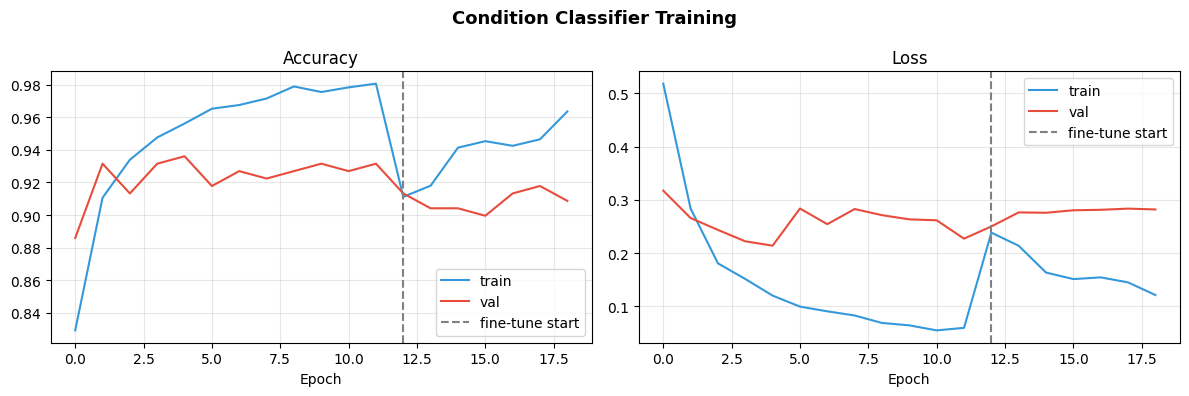

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Condition Classifier Training", fontsize=13, fontweight="bold")

axes[0].plot(full_history["accuracy"],     label="train", color="#3498DB")
axes[0].plot(full_history["val_accuracy"], label="val",   color="#E74C3C")
axes[0].axvline(len(history1.history["accuracy"]), linestyle="--", color="gray", label="fine-tune start")
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(full_history["loss"],     label="train", color="#3498DB")
axes[1].plot(full_history["val_loss"], label="val",   color="#E74C3C")
axes[1].axvline(len(history1.history["loss"]), linestyle="--", color="gray", label="fine-tune start")
axes[1].set_title("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel("Epoch")

plt.tight_layout()
plt.show()

### 6.6 Evaluate Classifier

Test Accuracy : 0.8909
Test Loss     : 0.3026
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 846ms/step

Classification Report:
              precision    recall  f1-score   support

    Daylight       1.00      0.43      0.60        14
       Night       0.95      0.96      0.95       176
    Twilight       0.58      0.70      0.64        30

    accuracy                           0.89       220
   macro avg       0.84      0.70      0.73       220
weighted avg       0.90      0.89      0.89       220



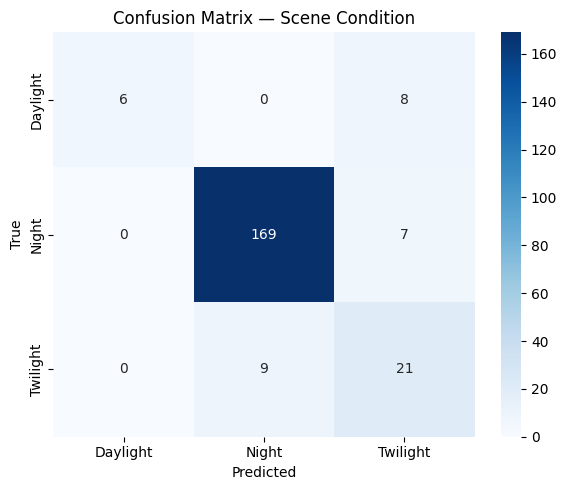

In [20]:
loss, acc = clf_model.evaluate(test_data, verbose=0)
print(f"Test Accuracy : {acc:.4f}")
print(f"Test Loss     : {loss:.4f}")

y_pred = np.argmax(clf_model.predict(test_data), axis=1)
y_true = test_data.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Confusion Matrix — Scene Condition")
ax.set_ylabel("True"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

## 7. 🔗 Dual-Output Inference Pipeline

Combines both models to produce **two outputs per image**:
1. YOLOv8 → bounding boxes with `Light_On` / `Light_Off`  
2. MobileNetV2 → scene condition `Night` / `Twilight` / `Daylight`

In [21]:
def predict_image(img_path: str,
                  yolo_model,
                  clf_model,
                  class_names: list,
                  conf_threshold: float = 0.25) -> dict:
    """
    Run both models on a single image.

    Returns
    -------
    dict with keys:
        detections  : list of {bbox, label, confidence}
        condition   : str  (Daylight / Twilight / Night)
        cond_conf   : float
    """
    # ── YOLO inference ────────────────────────────────────────────────────
    yolo_results = yolo_model(img_path, conf=conf_threshold, verbose=False)[0]
    detections   = []
    for box in yolo_results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cls_id = int(box.cls[0])
        conf   = float(box.conf[0])
        label  = yolo_results.names[cls_id]
        detections.append({
            "bbox"      : [x1, y1, x2, y2],
            "label"     : label,
            "confidence": round(conf, 3),
        })

    # ── Condition classifier inference ────────────────────────────────────
    img_rgb   = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMG_SIZE).astype("float32") / 255.0
    img_batch = np.expand_dims(img_resized, 0)

    probs     = clf_model.predict(img_batch, verbose=0)[0]
    cond_idx  = int(np.argmax(probs))
    condition = class_names[cond_idx]
    cond_conf = float(probs[cond_idx])

    return {
        "detections": detections,
        "condition" : condition,
        "cond_conf" : round(cond_conf, 3),
    }

In [28]:
def visualise_prediction(img_path: str, result: dict):
    """Draw bounding boxes (light status) and overlay scene condition."""
    img    = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w   = img.shape[:2]
    COLOURS= {"Light_On": (0, 220, 100), "Light_Off": (220, 50, 50)}
    COND_C = {"Daylight": (255, 220, 0), "Twilight": (255, 140, 0), "Night": (100, 149, 237)}

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(img)

    for det in result["detections"]:
        x1, y1, x2, y2 = det["bbox"]
        label  = det["label"]
        conf   = det["confidence"]
        colour = [c/255 for c in COLOURS.get(label, (200, 200, 200))]

        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=colour, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 6, f"{label} {conf:.2f}",
                color=colour, fontsize=9, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.4, pad=1, edgecolor="none"))

    cond   = result["condition"]
    cconf  = result["cond_conf"]
    ccolour= [c/255 for c in COND_C.get(cond, (255,255,255))]
    ax.text(8, 22, f"Scene: {cond}  ({cconf:.1%})",
            color=ccolour, fontsize=11, fontweight="bold",
            bbox=dict(facecolor="black", alpha=0.6, pad=3, edgecolor="none"))

    ax.axis("off")
    plt.tight_layout()
    plt.show()
    return result

### 7.1 Run Inference on Sample Test Images

Running inference on 6 test images...

Image  : 20240305_190254_jpg.rf.0e7999876f5269451c605d7218fe17c9.jpg
  Condition  : Night  (conf 99.9%)
  Detection  : Light_Off    conf=0.84  bbox=[np.int64(235), np.int64(182), np.int64(278), np.int64(215)]



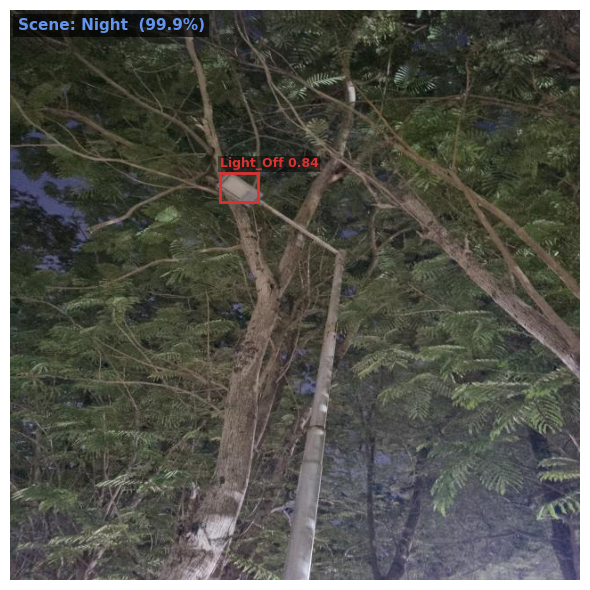

Image  : 20240305_192512_jpg.rf.30607bbf59e55754aac1b21570d0aea7.jpg
  Condition  : Night  (conf 100.0%)
  Detection  : Light_On     conf=0.82  bbox=[np.int64(273), np.int64(403), np.int64(344), np.int64(464)]



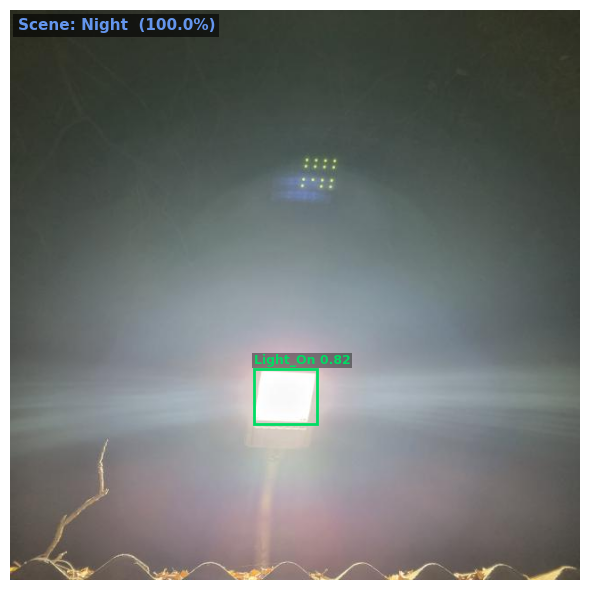

Image  : 1710161569875_jpg.rf.fb40ee7577cd5b1fafdb52b54e961a6a.jpg
  Condition  : Twilight  (conf 96.1%)
  Detection  : Light_On     conf=0.82  bbox=[np.int64(157), np.int64(178), np.int64(227), np.int64(210)]



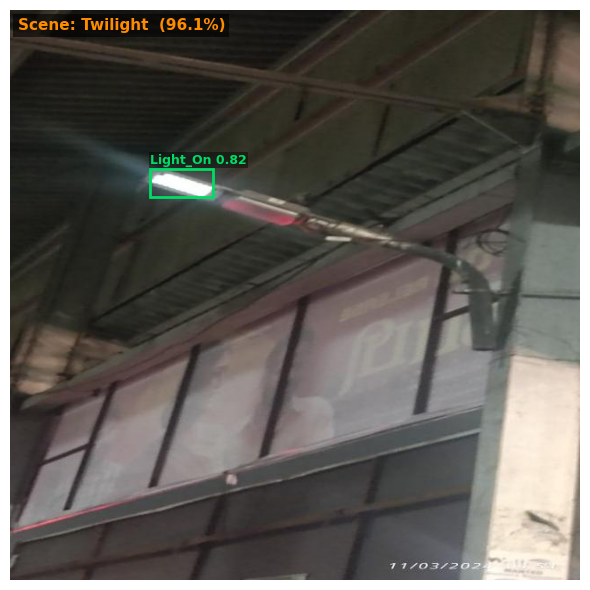

Image  : 1710161569905_jpg.rf.4de4db0bf659ea934f4db1b29dbd8edc.jpg
  Condition  : Night  (conf 100.0%)
  Detection  : Light_On     conf=0.73  bbox=[np.int64(214), np.int64(69), np.int64(321), np.int64(97)]



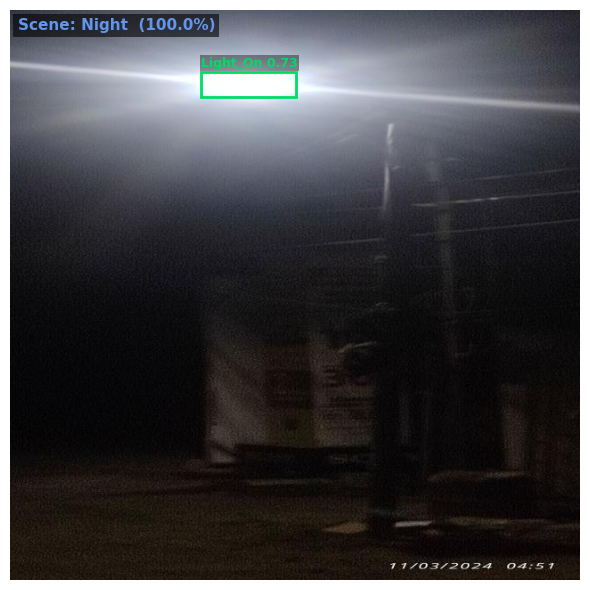

Image  : IMG-20240303-WA0033_jpg.rf.8086b971e08bb423fb9c300f31fbed11.jpg
  Condition  : Night  (conf 100.0%)
  Detection  : Light_On     conf=0.78  bbox=[np.int64(192), np.int64(177), np.int64(217), np.int64(196)]
  Detection  : Light_On     conf=0.76  bbox=[np.int64(427), np.int64(190), np.int64(466), np.int64(219)]
  Detection  : Light_On     conf=0.32  bbox=[np.int64(1), np.int64(263), np.int64(12), np.int64(269)]



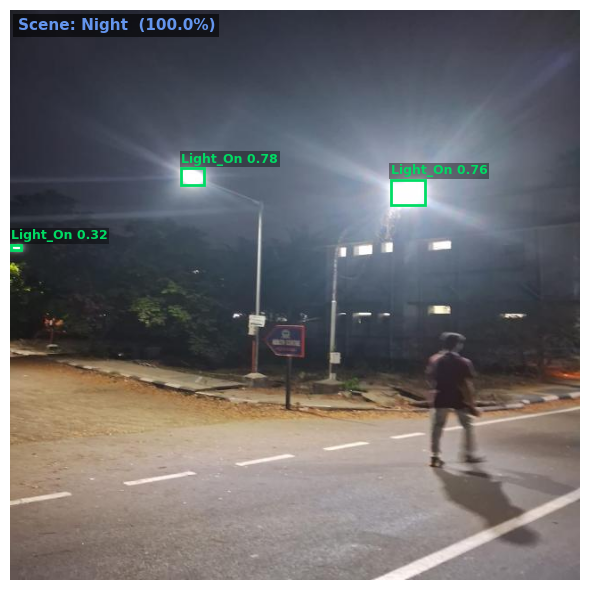

Image  : WhatsApp-Image-2024-03-05-at-21-00-45_8689db80_jpg.rf.7ce717f9a24c15ec72ec6958278d470c.jpg
  Condition  : Night  (conf 99.8%)
  Detection  : Light_On     conf=0.84  bbox=[np.int64(291), np.int64(165), np.int64(354), np.int64(199)]



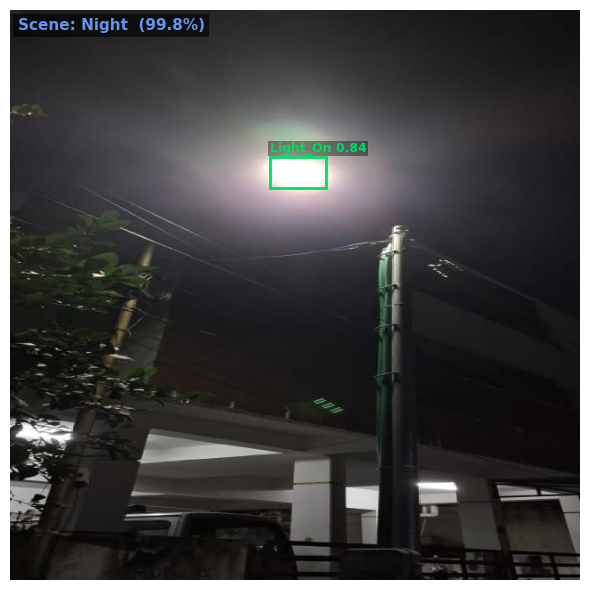

In [23]:
test_img_dir = f"{coco_root}/test"
test_images  = [
    os.path.join(test_img_dir, f)
    for f in os.listdir(test_img_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
][:6]   # show 6 examples

print(f"Running inference on {len(test_images)} test images...\n")

for img_path in test_images:
    result = predict_image(img_path, yolo_model, clf_model, CLASS_NAMES)
    print(f"Image  : {os.path.basename(img_path)}")
    print(f"  Condition  : {result['condition']}  (conf {result['cond_conf']:.1%})")
    for d in result["detections"]:
        print(f"  Detection  : {d['label']:12s} conf={d['confidence']:.2f}  bbox={d['bbox']}")
    print()
    visualise_prediction(img_path, result)

### 7.2 Batch Inference → Export Results to CSV

In [24]:
all_test_images = [
    os.path.join(test_img_dir, f)
    for f in os.listdir(test_img_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

rows = []
for img_path in tqdm(all_test_images, desc="Batch inference"):
    result = predict_image(img_path, yolo_model, clf_model, CLASS_NAMES)
    for det in result["detections"]:
        rows.append({
            "image"          : os.path.basename(img_path),
            "light_label"    : det["label"],
            "light_conf"     : det["confidence"],
            "bbox_x1"        : det["bbox"][0],
            "bbox_y1"        : det["bbox"][1],
            "bbox_x2"        : det["bbox"][2],
            "bbox_y2"        : det["bbox"][3],
            "scene_condition": result["condition"],
            "scene_conf"     : result["cond_conf"],
        })

results_df = pd.DataFrame(rows)
results_df.to_csv("/content/streetlight_predictions.csv", index=False)
print(f"Saved {len(results_df)} detection rows to /content/streetlight_predictions.csv")
results_df.head()

Batch inference: 100%|██████████| 43/43 [00:04<00:00, 10.03it/s]


Saved 67 detection rows to /content/streetlight_predictions.csv


,image,light_label,light_conf,bbox_x1,bbox_y1,bbox_x2,bbox_y2,scene_condition,scene_conf
0,20240305_190254_jpg.rf.0e7999876f5269451c605d7...,Light_Off,0.837,235,182,278,215,Night,0.999
1,20240305_192512_jpg.rf.30607bbf59e55754aac1b21...,Light_On,0.821,273,403,344,464,Night,1.000
2,1710161569875_jpg.rf.fb40ee7577cd5b1fafdb52b54...,Light_On,0.818,157,178,227,210,Twilight,0.961
3,1710161569905_jpg.rf.4de4db0bf659ea934f4db1b29...,Light_On,0.734,214,69,321,97,Night,1.000
4,IMG-20240303-WA0033_jpg.rf.8086b971e08bb423fb9...,Light_On,0.777,192,177,217,196,Night,1.000


## 8. 💾 Save Models

In [25]:
# ── Condition classifier ──────────────────────────────────────────────────
clf_model.save("/content/condition_classifier_final.h5")
print("Condition classifier saved to /content/condition_classifier_final.h5")

# ── YOLOv8 best weights are already saved by the trainer ─────────────────
print(f"YOLOv8 best weights : {best_weights}")

# Optional: export YOLO to ONNX for deployment
# yolo_model.export(format="onnx")

Condition classifier saved to /content/condition_classifier_final.h5
YOLOv8 best weights : /content/runs/streetlight_yolo/weights/best.pt


## 9. 📊 Summary

| | Model | Task | Output |
|---|---|---|---|
| **Detection** | YOLOv8n | Locate streetlights | BBox + `Light_On`/`Light_Off` + confidence |
| **Classification** | MobileNetV2 | Scene condition | `Night` / `Twilight` / `Daylight` + confidence |

### Pipeline Summary
```
Image
  │
  ├──► YOLOv8 ──────────────► [BBox, Light_On/Off, conf]
  │
  └──► MobileNetV2 ─────────► [Night / Twilight / Daylight, conf]
```

### Potential Fault Detection Rules
Fault conditions can be flagged programmatically using the combined outputs:

| Rule | Condition Detected | Light Status | Fault Type |
|------|--------------------|--------------|------------|
| 1 | Night or Twilight | `Light_Off` | **Lamp Out** |
| 2 | Daylight | `Light_On` | **Light Left On** (energy waste) |
| 3 | Night or Twilight | `Light_On` | ✅ Normal operation |

In [26]:
def flag_faults(df: pd.DataFrame) -> pd.DataFrame:
    """Apply fault detection logic to a predictions DataFrame."""
    conditions = [
        (df["scene_condition"].isin(["Night", "Twilight"])) & (df["light_label"] == "Light_Off"),
        (df["scene_condition"] == "Daylight") & (df["light_label"] == "Light_On"),
    ]
    choices = ["⚠️  LAMP OUT", "💡 LEFT ON"]
    df["fault"] = np.select(conditions, choices, default="✅ Normal")
    return df

results_df = flag_faults(results_df)
print(results_df["fault"].value_counts())

results_df.to_csv("/content/streetlight_predictions_with_faults.csv", index=False)
print("\nFinal predictions with fault flags saved.")
results_df.head(10)

fault
✅ Normal        44
⚠️  LAMP OUT    23
Name: count, dtype: int64

Final predictions with fault flags saved.


,image,light_label,light_conf,bbox_x1,bbox_y1,bbox_x2,bbox_y2,scene_condition,scene_conf,fault
0,20240305_190254_jpg.rf.0e7999876f5269451c605d7...,Light_Off,0.837,235,182,278,215,Night,0.999,⚠️ LAMP OUT
1,20240305_192512_jpg.rf.30607bbf59e55754aac1b21...,Light_On,0.821,273,403,344,464,Night,1.000,✅ Normal
2,1710161569875_jpg.rf.fb40ee7577cd5b1fafdb52b54...,Light_On,0.818,157,178,227,210,Twilight,0.961,✅ Normal
3,1710161569905_jpg.rf.4de4db0bf659ea934f4db1b29...,Light_On,0.734,214,69,321,97,Night,1.000,✅ Normal
4,IMG-20240303-WA0033_jpg.rf.8086b971e08bb423fb9...,Light_On,0.777,192,177,217,196,Night,1.000,✅ Normal
5,IMG-20240303-WA0033_jpg.rf.8086b971e08bb423fb9...,Light_On,0.759,427,190,466,219,Night,1.000,✅ Normal
6,IMG-20240303-WA0033_jpg.rf.8086b971e08bb423fb9...,Light_On,0.322,1,263,12,269,Night,1.000,✅ Normal
7,WhatsApp-Image-2024-03-05-at-21-00-45_8689db80...,Light_On,0.843,291,165,354,199,Night,0.998,✅ Normal
8,20240305_192619_jpg.rf.3c0d712a821205c583464fe...,Light_Off,0.810,224,245,316,332,Night,1.000,⚠️ LAMP OUT
9,703_original_jpg.rf.f344c7b81f90d0fd10453de1f0...,Light_Off,0.595,59,432,234,456,Daylight,0.970,✅ Normal
